<a href="https://colab.research.google.com/github/FaridRash/brain-ct-hemorrhage-segmentation/blob/main/Notebooks/Segmentation/02_conversion_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Integrity Check

In [43]:
pip install nibabel

Note: you may need to restart the kernel to use updated packages.


In [44]:
import os
import nibabel as nib

ct_path = "D:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\ct_scans"
mask_path = "D:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\masks"

# get one sample file
ct_file = sorted(os.listdir(ct_path))[0]
mask_file = sorted(os.listdir(mask_path))[0]

print("CT file:", ct_file)
print("Mask file:", mask_file)

# load
ct_img = nib.load(os.path.join(ct_path, ct_file))
mask_img = nib.load(os.path.join(mask_path, mask_file))

# convert to numpy
ct_data = ct_img.get_fdata()
mask_data = mask_img.get_fdata()

# print info
print("\nCT shape:", ct_data.shape)
print("Mask shape:", mask_data.shape)

print("\nCT dtype:", ct_data.dtype)
print("Mask dtype:", mask_data.dtype)

print("\nCT spacing:", ct_img.header.get_zooms())
print("Mask spacing:", mask_img.header.get_zooms())

CT file: 049.nii
Mask file: 049.nii

CT shape: (512, 512, 39)
Mask shape: (512, 512, 39)

CT dtype: float64
Mask dtype: float64

CT spacing: (np.float32(0.41210938), np.float32(0.41210938), np.float32(5.0))
Mask spacing: (np.float32(0.41210938), np.float32(0.41210938), np.float32(5.0))


Shape: (512, 512, 39) → standard axial CT (39 slices)

Spacing:

x,y ≈ 0.41 mm (high resolution)

z = 5.0 mm (thick slices → low resolution in depth)

In [45]:
import nibabel as nib

print("CT orientation:", nib.aff2axcodes(ct_img.affine))
print("Mask orientation:", nib.aff2axcodes(mask_img.affine))

CT orientation: ('L', 'A', 'S')
Mask orientation: ('L', 'A', 'S')


Same orientation

No flipping issue

**The CT and mask are pixel-wise aligned**

# Visual Alignment Check

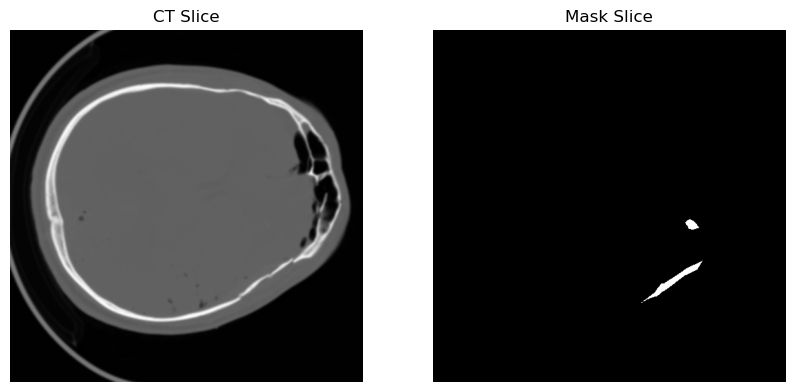

In [46]:
import matplotlib.pyplot as plt

slice_idx = 20  # middle slice

plt.figure(figsize=(10,5))

# CT image
plt.subplot(1,2,1)
plt.imshow(ct_data[:, :, slice_idx], cmap='gray')
plt.title("CT Slice")
plt.axis("off")

# Mask
plt.subplot(1,2,2)
plt.imshow(mask_data[:, :, slice_idx], cmap='gray')
plt.title("Mask Slice")
plt.axis("off")

plt.show()

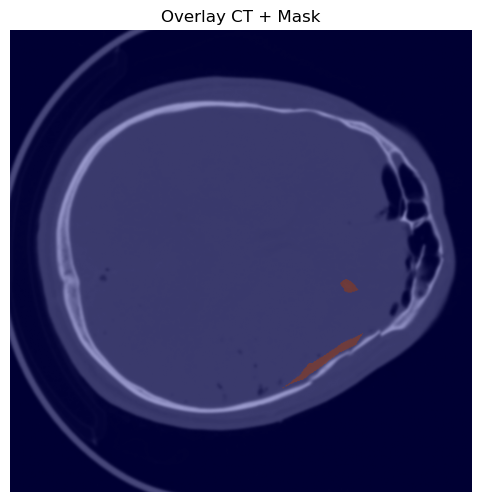

In [47]:
plt.figure(figsize=(6,6))
plt.imshow(ct_data[:, :, slice_idx], cmap='gray')
plt.imshow(mask_data[:, :, slice_idx], cmap='jet', alpha=0.4)
plt.title("Overlay CT + Mask")
plt.axis("off")
plt.show()

In [48]:
import numpy as np

print("Unique mask values:", np.unique(mask_data))

Unique mask values: [  0.         254.99999994]


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

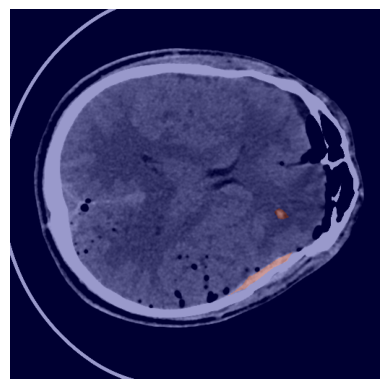

In [49]:
def window_ct(img, level=40, width=80):
    min_val = level - width // 2
    max_val = level + width // 2
    img = np.clip(img, min_val, max_val)
    img = (img - min_val) / (max_val - min_val)
    return img

ct_windowed = window_ct(ct_data[:, :, 20])

plt.imshow(ct_windowed, cmap='gray')
plt.imshow(mask_data[:, :, 20], cmap='jet', alpha=0.4)
plt.axis("off")

In [50]:
ct_slice = ct_data[:, :, 20]
mask_slice = mask_data[:, :, 20]

masked_pixels = ct_slice[mask_slice > 0]

print("Mean intensity inside mask:", masked_pixels.mean())
print("Mean intensity outside mask:", ct_slice[mask_slice == 0].mean())

Mean intensity inside mask: 68.92247191011236
Mean intensity outside mask: -380.0355209872385


# Conversion

## Train

In [51]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [52]:
import pandas as pd

train_split_path = "G:\\My Drive\\brain_ct_project\\splits\\train_scans.csv"

df_train = pd.read_csv(train_split_path)

train_scan_list = df_train["scan_id"].values

print("Train scans:", len(train_scan_list))
print("First 5 train IDs:", train_scan_list[:5])

Train scans: 60
First 5 train IDs: [ 71  81 108 127  79]


In [53]:
train_pairs = []

for scan_id in train_scan_list:

    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        train_pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched train pairs:", len(train_pairs))

Total matched train pairs: 60


In [54]:
import os

ct_path = "D:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\ct_scans"
mask_path = "D:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\masks"

train_pairs = []

for scan_id in train_scan_list:

    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        train_pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched train pairs:", len(train_pairs))
print("First 5 train pairs:", train_pairs[:5])

Total matched train pairs: 60
First 5 train pairs: [('071.nii', '071.nii'), ('081.nii', '081.nii'), ('108.nii', '108.nii'), ('127.nii', '127.nii'), ('079.nii', '079.nii')]


In [55]:
train_image_slices = []
train_mask_slices = []

for ct_file, mask_file in train_pairs:

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    ct_vol = nib.load(ct_full_path).get_fdata()
    mask_vol = nib.load(mask_full_path).get_fdata()

    for i in range(ct_vol.shape[2]):

        img_slice = ct_vol[:, :, i]
        mask_slice = mask_vol[:, :, i]

        train_image_slices.append(img_slice)
        train_mask_slices.append(mask_slice)

print("Total train slices:", len(train_image_slices))

Total train slices: 2281


In [56]:
import os

base_dir = "D:\\My Projects\\Temp\\brain_ct_segmentation_data"

train_dir = os.path.join(base_dir, "train")

train_img_npy_dir = os.path.join(train_dir, "images")
train_mask_npy_dir = os.path.join(train_dir, "masks")

for d in [train_img_npy_dir, train_mask_npy_dir]:
    os.makedirs(d, exist_ok=True)

print("Saving train to:", train_dir)

Saving train to: D:\My Projects\Temp\brain_ct_segmentation_data\train


## Val

In [57]:
import pandas as pd

val_split_path = "G:\\My Drive\\brain_ct_project\\splits\\val_scans.csv"

df_val = pd.read_csv(val_split_path)

val_scan_list = df_val["scan_id"].values

print("Val scans:", len(val_scan_list))
print("First 5 val IDs:", val_scan_list[:5])

Val scans: 7
First 5 val IDs: [ 87  52 112 102 114]


In [58]:
val_pairs = []

for scan_id in val_scan_list:

    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        val_pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched val pairs:", len(val_pairs))

Total matched val pairs: 7


In [59]:
import os

ct_path = "D:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\ct_scans"
mask_path = "D:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\masks"

val_pairs = []

for scan_id in val_scan_list:

    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        val_pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched val pairs:", len(val_pairs))
print("First 5 val pairs:", val_pairs[:5])

Total matched val pairs: 7
First 5 val pairs: [('087.nii', '087.nii'), ('052.nii', '052.nii'), ('112.nii', '112.nii'), ('102.nii', '102.nii'), ('114.nii', '114.nii')]


In [60]:
val_image_slices = []
val_mask_slices = []

for ct_file, mask_file in val_pairs:

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    ct_vol = nib.load(ct_full_path).get_fdata()
    mask_vol = nib.load(mask_full_path).get_fdata()

    for i in range(ct_vol.shape[2]):

        img_slice = ct_vol[:, :, i]
        mask_slice = mask_vol[:, :, i]

        val_image_slices.append(img_slice)
        val_mask_slices.append(mask_slice)

print("Total val slices:", len(val_image_slices))

Total val slices: 241


In [61]:
import os

base_dir = "D:\\My Projects\\Temp\\brain_ct_segmentation_data"

val_dir = os.path.join(base_dir, "val")

val_img_npy_dir = os.path.join(val_dir, "images")
val_mask_npy_dir = os.path.join(val_dir, "masks")

for d in [val_img_npy_dir, val_mask_npy_dir]:
    os.makedirs(d, exist_ok=True)

print("Saving val to:", val_dir)

Saving val to: D:\My Projects\Temp\brain_ct_segmentation_data\val


## Test

In [62]:
test_split_path = "G:\\My Drive\\brain_ct_project\\splits\\test_scans.csv"

df_test = pd.read_csv(test_split_path)

test_scan_list = df_test["scan_id"].values

print("Test scans:", len(test_scan_list))
print("First 5 test IDs:", test_scan_list[:5])

Test scans: 8
First 5 test IDs: [ 84 106 130  77 120]


In [63]:
test_pairs = []

for scan_id in test_scan_list:

    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        test_pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched test pairs:", len(test_pairs))

Total matched test pairs: 8


In [64]:
import os

ct_path = "D:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\ct_scans"
mask_path = "D:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\masks"

test_pairs = []

for scan_id in test_scan_list:

    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        test_pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched test pairs:", len(test_pairs))
print("First 5 test pairs:", test_pairs[:5])

Total matched test pairs: 8
First 5 test pairs: [('084.nii', '084.nii'), ('106.nii', '106.nii'), ('130.nii', '130.nii'), ('077.nii', '077.nii'), ('120.nii', '120.nii')]


In [65]:
test_image_slices = []
test_mask_slices = []

for ct_file, mask_file in test_pairs:

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    ct_vol = nib.load(ct_full_path).get_fdata()
    mask_vol = nib.load(mask_full_path).get_fdata()

    for i in range(ct_vol.shape[2]):

        img_slice = ct_vol[:, :, i]
        mask_slice = mask_vol[:, :, i]

        test_image_slices.append(img_slice)
        test_mask_slices.append(mask_slice)

print("Total test slices:", len(test_image_slices))

Total test slices: 292


In [66]:
import os

base_dir = "D:\\My Projects\\Temp\\brain_ct_segmentation_data"

test_dir = os.path.join(base_dir, "test")

test_img_npy_dir = os.path.join(test_dir, "images")
test_mask_npy_dir = os.path.join(test_dir, "masks")

for d in [test_img_npy_dir, test_mask_npy_dir]:
    os.makedirs(d, exist_ok=True)

print("Saving test to:", test_dir)

Saving test to: D:\My Projects\Temp\brain_ct_segmentation_data\test


# Save Data

## Save the files

### Train

#### Load split

In [67]:
import pandas as pd

train_split_path = "G:\\My Drive\\brain_ct_project\\splits\\train_scans.csv"

df_train = pd.read_csv(train_split_path)
train_scan_list = df_train["scan_id"].astype(str).values

print("Train scans:", len(train_scan_list))

Train scans: 60


#### Build valid scan pairs

In [68]:
import os

train_pairs = []

for scan_id in train_scan_list:
    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full) and os.path.exists(mask_full):
        train_pairs.append((ct_full, mask_full))

print("Train pairs:", len(train_pairs))

Train pairs: 60


#### Prepare output folders

In [69]:
import shutil

base_dir = "D:\\My Projects\\Temp\\brain_ct_segmentation_data"

train_img_dir = os.path.join(base_dir, "train", "images")
train_mask_dir = os.path.join(base_dir, "train", "masks")

shutil.rmtree(os.path.join(base_dir, "train"), ignore_errors=True)

os.makedirs(train_img_dir, exist_ok=True)
os.makedirs(train_mask_dir, exist_ok=True)

print("Saving to:", train_img_dir)

Saving to: D:\My Projects\Temp\brain_ct_segmentation_data\train\images


#### Convert + CLEAN + Save

In [70]:
import numpy as np
import nibabel as nib
from tqdm import tqdm

LOW = 20
HIGH = 120

slice_idx = 0

for ct_path_full, mask_path_full in tqdm(train_pairs):

    ct_vol = nib.load(ct_path_full).get_fdata()
    mask_vol = nib.load(mask_path_full).get_fdata()

    for i in range(ct_vol.shape[2]):

        img = ct_vol[:, :, i].astype(np.float32)
        mask = mask_vol[:, :, i]

        # --- binarize mask ---
        mask = (mask > 0)

        # --- CLEAN MASK using HU ---
        valid_region = (img >= LOW) & (img <= HIGH)
        clean_mask = (mask & valid_region).astype(np.uint8)

        # --- SAVE ---
        np.save(os.path.join(train_img_dir, f"slice_{slice_idx:05d}.npy"), img)
        np.save(os.path.join(train_mask_dir, f"slice_{slice_idx:05d}.npy"), clean_mask)

        slice_idx += 1

print("Total slices saved:", slice_idx)
print("TRAIN DONE")

100%|██████████| 60/60 [00:26<00:00,  2.27it/s]

Total slices saved: 2281
TRAIN DONE


#### Quick sanity check

In [71]:
print("Images:", len(os.listdir(train_img_dir)))
print("Masks :", len(os.listdir(train_mask_dir)))

Images: 2281
Masks : 2281


In [72]:
img = np.load(os.path.join(train_img_dir, "slice_00000.npy"))
print(img.min(), img.max())

-1024.0 1391.0


### Val

#### Load validation split

In [73]:
import pandas as pd

val_split_path = "G:\\My Drive\\brain_ct_project\\splits\\val_scans.csv"

df_val = pd.read_csv(val_split_path)
val_scan_list = df_val["scan_id"].astype(str).values

print("Val scans:", len(val_scan_list))

Val scans: 7


#### Build scan pairs

In [74]:
import os

val_pairs = []

for scan_id in val_scan_list:
    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full) and os.path.exists(mask_full):
        val_pairs.append((ct_full, mask_full))

print("Val pairs:", len(val_pairs))

Val pairs: 7


#### Prepare output folders

In [75]:
import shutil

base_dir = "D:\\My Projects\\Temp\\brain_ct_segmentation_data"

val_img_dir = os.path.join(base_dir, "val", "images")
val_mask_dir = os.path.join(base_dir, "val", "masks")

shutil.rmtree(os.path.join(base_dir, "val"), ignore_errors=True)

os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_mask_dir, exist_ok=True)

print("Saving to:", val_img_dir)

Saving to: D:\My Projects\Temp\brain_ct_segmentation_data\val\images


#### Convert + CLEAN + Save

In [76]:
import numpy as np
import nibabel as nib
from tqdm import tqdm

LOW = 20
HIGH = 120

slice_idx = 0

for ct_path_full, mask_path_full in tqdm(val_pairs):

    ct_vol = nib.load(ct_path_full).get_fdata()
    mask_vol = nib.load(mask_path_full).get_fdata()

    for i in range(ct_vol.shape[2]):

        img = ct_vol[:, :, i].astype(np.float32)
        mask = mask_vol[:, :, i]

        # --- binarize ---
        mask = (mask > 0)

        # --- CLEAN ---
        valid_region = (img >= LOW) & (img <= HIGH)
        clean_mask = (mask & valid_region).astype(np.uint8)

        # --- SAVE ---
        np.save(os.path.join(val_img_dir, f"slice_{slice_idx:05d}.npy"), img)
        np.save(os.path.join(val_mask_dir, f"slice_{slice_idx:05d}.npy"), clean_mask)

        slice_idx += 1

print("Total val slices:", slice_idx)
print("VAL DONE")

100%|██████████| 7/7 [00:02<00:00,  3.04it/s]

Total val slices: 241
VAL DONE


#### Sanity check

In [77]:
print("Images:", len(os.listdir(val_img_dir)))
print("Masks :", len(os.listdir(val_mask_dir)))

Images: 241
Masks : 241


### Test

#### Load test split

In [78]:
import pandas as pd

test_split_path = "G:\\My Drive\\brain_ct_project\\splits\\test_scans.csv"

df_test = pd.read_csv(test_split_path)
test_scan_list = df_test["scan_id"].astype(str).values

print("Test scans:", len(test_scan_list))

Test scans: 8


#### Build scan pairs

In [79]:
import os

test_pairs = []

for scan_id in test_scan_list:
    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full) and os.path.exists(mask_full):
        test_pairs.append((ct_full, mask_full))

print("Test pairs:", len(test_pairs))

Test pairs: 8


#### Prepare output folders

In [80]:
import shutil

base_dir = "D:\\My Projects\\Temp\\brain_ct_segmentation_data"

test_img_dir = os.path.join(base_dir, "test", "images")
test_mask_dir = os.path.join(base_dir, "test", "masks")

shutil.rmtree(os.path.join(base_dir, "test"), ignore_errors=True)

os.makedirs(test_img_dir, exist_ok=True)
os.makedirs(test_mask_dir, exist_ok=True)

print("Saving to:", test_img_dir)

Saving to: D:\My Projects\Temp\brain_ct_segmentation_data\test\images


#### Convert + CLEAN + Save

In [81]:
import numpy as np
import nibabel as nib
from tqdm import tqdm

LOW = 20
HIGH = 120

slice_idx = 0

for ct_path_full, mask_path_full in tqdm(test_pairs):

    ct_vol = nib.load(ct_path_full).get_fdata()
    mask_vol = nib.load(mask_path_full).get_fdata()

    for i in range(ct_vol.shape[2]):

        img = ct_vol[:, :, i].astype(np.float32)
        mask = mask_vol[:, :, i]

        # --- binarize ---
        mask = (mask > 0)

        # --- CLEAN ---
        valid_region = (img >= LOW) & (img <= HIGH)
        clean_mask = (mask & valid_region).astype(np.uint8)

        # --- SAVE ---
        np.save(os.path.join(test_img_dir, f"slice_{slice_idx:05d}.npy"), img)
        np.save(os.path.join(test_mask_dir, f"slice_{slice_idx:05d}.npy"), clean_mask)

        slice_idx += 1

print("Total test slices:", slice_idx)
print("TEST DONE")

100%|██████████| 8/8 [00:02<00:00,  2.71it/s]

Total test slices: 292
TEST DONE


#### Sanity check

In [82]:
print("Images:", len(os.listdir(test_img_dir)))
print("Masks :", len(os.listdir(test_mask_dir)))

Images: 292
Masks : 292


## Test the data

In [83]:
import os

for split in ["train", "val", "test"]:
    path = f"D:\\My Projects\\Temp\\brain_ct_segmentation_data\\{split}\\images"
    if os.path.exists(path):
        print(split, len(os.listdir(path)))
    else:
        print(split, "NOT CREATED")

train 2281
val 241
test 292


# Export zipped files to Google.Drive

In [84]:
import shutil
import os

# source folder
source_dir = "D:\\My Projects\\Temp\\brain_ct_segmentation_data"

# destination (Drive)
save_dir = "G:\\My Drive\\brain_ct_project"
os.makedirs(save_dir, exist_ok=True)

# destination folder path (final copied folder)
dest_folder = os.path.join(save_dir, "processed_data_full")

# if folder already exists → remove it (important to avoid errors)
if os.path.exists(dest_folder):
    shutil.rmtree(dest_folder)

# copy entire folder
shutil.copytree(source_dir, dest_folder)

print("Folder copied to:", dest_folder)

Folder copied to: G:\My Drive\brain_ct_project\processed_data_full
